In [5]:
# Cell 1: Import required libraries

import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from scipy.sparse import hstack

print("All libraries imported successfully!")

All libraries imported successfully!


In [6]:
# Cell 2: Load Chicago Crime dataset

df = pd.read_csv("chicago_crime.csv.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
Dataset shape: (759290, 22)

Columns:
['python -m pip install --upgrade pip"ID"', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude', 'Location']

First 5 rows:


,"python -m pip install --upgrade pip""ID""",Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,14070466,JJ540292,12/31/2025 02:30:00 PM,001XX W 112TH PL,0910,MOTOR VEHICLE THEFT,AUTOMOBILE,STREET,False,False,...,9.0,49.0,07,1177249.0,1830354.0,2025,03/14/2026 03:41:39 PM,41.689820,-87.626713,"(41.689820475, -87.626712685)"
1,14070469,JJ540385,12/31/2025 02:30:00 PM,048XX S LAKE PARK AVE,0560,ASSAULT,SIMPLE,STREET,False,False,...,4.0,39.0,08A,1186953.0,1873098.0,2025,03/14/2026 03:41:39 PM,41.806890,-87.589834,"(41.806890268, -87.589834384)"
2,14070549,JJ540301,12/31/2025 02:30:00 PM,106XX S AVENUE M,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,False,True,...,10.0,52.0,08B,1201519.0,1835022.0,2025,03/14/2026 03:41:39 PM,41.702049,-87.537704,"(41.702049219, -87.53770369)"
3,14078959,JK109689,12/31/2025 02:30:00 PM,038XX S VINCENNES AVE,0820,THEFT,$500 AND UNDER,APARTMENT,False,False,...,4.0,35.0,06,1180774.0,1879690.0,2025,03/14/2026 03:41:39 PM,41.825124,-87.612294,"(41.825123682, -87.61229385)"
4,14070546,JJ540340,12/31/2025 02:24:00 PM,010XX S MICHIGAN AVE,1330,CRIMINAL TRESPASS,TO LAND,APARTMENT,True,False,...,4.0,32.0,26,1177416.0,1895928.0,2025,03/14/2026 03:41:39 PM,41.869759,-87.624121,"(41.86975858, -87.624121338)"


In [7]:
# Cell 3: Fix the incorrect first column name

print("Original first column name:")
print(df.columns[0])

# Rename the incorrect first column to Case Number
df = df.rename(columns={
    df.columns[0]: "Case Number"
})

print("\nUpdated first column name:")
print(df.columns[0])

print("\nDataset shape after column-name correction:")
print(df.shape)

Original first column name:
python -m pip install --upgrade pip"ID"

Updated first column name:
Case Number

Dataset shape after column-name correction:
(759290, 22)


In [8]:
# Cell 4: Create the Patrol_Requirement target

top_10_crimes = [
    "THEFT",
    "BATTERY",
    "CRIMINAL DAMAGE",
    "ASSAULT",
    "DECEPTIVE PRACTICE",
    "OTHER OFFENSE",
    "MOTOR VEHICLE THEFT",
    "NARCOTICS",
    "BURGLARY",
    "ROBBERY"
]

# Create binary target
df["Patrol_Requirement"] = (
    df["Primary Type"].isin(top_10_crimes).astype(int)
)

print("Target created successfully!")

print("\nPatrol Requirement counts:")
print(df["Patrol_Requirement"].value_counts())

print("\nPatrol Requirement percentage:")
print(df["Patrol_Requirement"].value_counts(normalize=True) * 100)

print("\nCrime type vs Patrol Requirement:")
print(
    df.groupby(["Primary Type", "Patrol_Requirement"])
      .size()
      .sort_values(ascending=False)
)

Target created successfully!

Patrol Requirement counts:
Patrol_Requirement
1    695674
0     63616
Name: count, dtype: int64

Patrol Requirement percentage:
Patrol_Requirement
1    91.621647
0     8.378353
Name: proportion, dtype: float64

Crime type vs Patrol Requirement:
Primary Type                       Patrol_Requirement
THEFT                              1                     173112
BATTERY                            1                     132836
CRIMINAL DAMAGE                    1                      84730
MOTOR VEHICLE THEFT                1                      68162
ASSAULT                            1                      67644
OTHER OFFENSE                      1                      49631
DECEPTIVE PRACTICE                 1                      49097
ROBBERY                            1                      25952
BURGLARY                           1                      25647
WEAPONS VIOLATION                  0                      21832
NARCOTICS                      

In [9]:
# Cell 5: Convert Date and create time features

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Create time-based features
df["Hour"] = df["Date"].dt.hour
df["Day_of_Week"] = df["Date"].dt.dayofweek

print("Date conversion completed!")

print("\nDate range:")
print("Start:", df["Date"].min())
print("End  :", df["Date"].max())

print("\nMissing Date values:")
print(df["Date"].isna().sum())

print("\nNew time features:")
display(df[["Date", "Hour", "Day_of_Week"]].head())

C:\Users\aru12\AppData\Local\Temp\ipykernel_22924\4116788777.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"], errors="coerce")


Date conversion completed!

Date range:
Start: 2023-01-01 14:36:00
End  : 2025-12-31 14:30:00

Missing Date values:
0

New time features:


,Date,Hour,Day_of_Week
0,2025-12-31 14:30:00,14,2
1,2025-12-31 14:30:00,14,2
2,2025-12-31 14:30:00,14,2
3,2025-12-31 14:30:00,14,2
4,2025-12-31 14:24:00,14,2


In [10]:
# Cell 6: Sort data chronologically

df = df.sort_values("Date").reset_index(drop=True)

print("Data sorted chronologically!")

print("\nFirst 5 dates:")
print(df["Date"].head())

print("\nLast 5 dates:")
print(df["Date"].tail())

Data sorted chronologically!

First 5 dates:
0   2023-01-01 14:36:00
1   2023-01-01 14:38:00
2   2023-01-01 14:39:00
3   2023-01-01 14:40:00
4   2023-01-01 14:45:00
Name: Date, dtype: datetime64[us]

Last 5 dates:
759285   2025-12-31 14:24:00
759286   2025-12-31 14:30:00
759287   2025-12-31 14:30:00
759288   2025-12-31 14:30:00
759289   2025-12-31 14:30:00
Name: Date, dtype: datetime64[us]


In [11]:
# Cell 7: Create chronological train-validation split

split_index = int(len(df) * 0.75)

train_df = df.iloc[:split_index].copy()
val_df = df.iloc[split_index:].copy()

print("Chronological split completed!")

print("\nTraining dataset shape:")
print(train_df.shape)

print("\nValidation dataset shape:")
print(val_df.shape)

print("\n========== TRAINING PERIOD ==========")
print("Start:", train_df["Date"].min())
print("End  :", train_df["Date"].max())

print("\n========== VALIDATION PERIOD ==========")
print("Start:", val_df["Date"].min())
print("End  :", val_df["Date"].max())

print("\n========== TARGET DISTRIBUTION ==========")

print("\nTraining:")
print(train_df["Patrol_Requirement"].value_counts())

print("\nValidation:")
print(val_df["Patrol_Requirement"].value_counts())


Chronological split completed!

Training dataset shape:
(569467, 25)

Validation dataset shape:
(189823, 25)

========== TRAINING PERIOD ==========
Start: 2023-01-01 14:36:00
End  : 2025-03-20 13:30:00

========== VALIDATION PERIOD ==========
Start: 2025-03-20 13:30:00
End  : 2025-12-31 14:30:00

========== TARGET DISTRIBUTION ==========

Training:
Patrol_Requirement
1    521352
0     48115
Name: count, dtype: int64

Validation:
Patrol_Requirement
1    174322
0     15501
Name: count, dtype: int64


In [12]:
# Cell 7: Create chronological train-validation split

split_index = int(len(df) * 0.75)

train_df = df.iloc[:split_index].copy()
val_df = df.iloc[split_index:].copy()

print("Chronological split completed!")

print("\nTraining dataset shape:")
print(train_df.shape)

print("\nValidation dataset shape:")
print(val_df.shape)

print("\n========== TRAINING PERIOD ==========")
print("Start:", train_df["Date"].min())
print("End  :", train_df["Date"].max())

print("\n========== VALIDATION PERIOD ==========")
print("Start:", val_df["Date"].min())
print("End  :", val_df["Date"].max())

print("\n========== TARGET DISTRIBUTION ==========")

print("\nTraining:")
print(train_df["Patrol_Requirement"].value_counts())

print("\nValidation:")
print(val_df["Patrol_Requirement"].value_counts())

Chronological split completed!

Training dataset shape:
(569467, 25)

Validation dataset shape:
(189823, 25)

========== TRAINING PERIOD ==========
Start: 2023-01-01 14:36:00
End  : 2025-03-20 13:30:00

========== VALIDATION PERIOD ==========
Start: 2025-03-20 13:30:00
End  : 2025-12-31 14:30:00

========== TARGET DISTRIBUTION ==========

Training:
Patrol_Requirement
1    521352
0     48115
Name: count, dtype: int64

Validation:
Patrol_Requirement
1    174322
0     15501
Name: count, dtype: int64


In [13]:
# Cell 8: Check missing values in train and validation data

check_columns = [
    "Location Description",
    "Arrest",
    "Domestic",
    "Beat",
    "District",
    "Ward",
    "Community Area",
    "X Coordinate",
    "Y Coordinate",
    "Year",
    "Latitude",
    "Longitude"
]

print("========== MISSING VALUES: TRAINING ==========")
print(train_df[check_columns].isnull().sum())

print("\n========== MISSING VALUES: VALIDATION ==========")
print(val_df[check_columns].isnull().sum())

========== MISSING VALUES: TRAINING ==========
Location Description    2900
Arrest                     0
Domestic                   0
Beat                       0
District                   0
Ward                       3
Community Area            27
X Coordinate            4603
Y Coordinate            4603
Year                       0
Latitude                4603
Longitude               4603
dtype: int64

========== MISSING VALUES: VALIDATION ==========
Location Description    967
Arrest                    0
Domestic                  0
Beat                      0
District                  0
Ward                      1
Community Area            8
X Coordinate            809
Y Coordinate            809
Year                      0
Latitude                809
Longitude               809
dtype: int64


In [14]:
# Cell 9: Handle missing numerical values

numeric_columns = [
    "Ward",
    "Community Area",
    "X Coordinate",
    "Y Coordinate",
    "Year",
    "Latitude",
    "Longitude",
    "Hour",
    "Day_of_Week"
]

for column in numeric_columns:
    median_value = train_df[column].median()
    
    train_df[column] = train_df[column].fillna(median_value)
    val_df[column] = val_df[column].fillna(median_value)

print("Missing numerical values handled.")

print("\nTraining missing values:")
print(train_df[numeric_columns].isnull().sum().sum())

print("\nValidation missing values:")
print(val_df[numeric_columns].isnull().sum().sum())

Missing numerical values handled.

Training missing values:
0

Validation missing values:
0


In [15]:
# Cell 10: Define features and target

target_column = "Patrol_Requirement"

categorical_columns = [
    "Block",
    "Location Description"
]

numeric_columns = [
    "Arrest",
    "Domestic",
    "Beat",
    "District",
    "Ward",
    "Community Area",
    "X Coordinate",
    "Y Coordinate",
    "Year",
    "Latitude",
    "Longitude",
    "Hour",
    "Day_of_Week"
]

feature_columns = categorical_columns + numeric_columns

X_train_raw = train_df[feature_columns].copy()
X_val_raw = val_df[feature_columns].copy()

y_train = train_df[target_column].copy()
y_val = val_df[target_column].copy()

print("Features and target created.")

print("\nFeature columns:")
print(feature_columns)

print("\nX_train shape:", X_train_raw.shape)
print("X_val shape:", X_val_raw.shape)

print("\ny_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

Features and target created.

Feature columns:
['Block', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'X Coordinate', 'Y Coordinate', 'Year', 'Latitude', 'Longitude', 'Hour', 'Day_of_Week']

X_train shape: (569467, 15)
X_val shape: (189823, 15)

y_train shape: (569467,)
y_val shape: (189823,)


In [16]:
# Cell 11: One-hot encode categorical features

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

# Fit ONLY on training data
encoder.fit(X_train_raw[categorical_columns])

X_train_cat = encoder.transform(X_train_raw[categorical_columns])
X_val_cat = encoder.transform(X_val_raw[categorical_columns])

print("Categorical encoding completed.")

print("Encoded categorical features:",
      len(encoder.get_feature_names_out(categorical_columns)))

print("Training categorical shape:", X_train_cat.shape)
print("Validation categorical shape:", X_val_cat.shape)

Categorical encoding completed.
Encoded categorical features: 33310
Training categorical shape: (569467, 33310)
Validation categorical shape: (189823, 33310)


In [17]:
# Cell 12: Prepare numerical features

# Convert Boolean values to 0/1 and ensure all features are numeric
X_train_num = X_train_raw[numeric_columns].astype(float).values
X_val_num = X_val_raw[numeric_columns].astype(float).values

print("Numerical features prepared.")

print("Training numerical shape:", X_train_num.shape)
print("Validation numerical shape:", X_val_num.shape)

print("\nTraining numerical data type:", X_train_num.dtype)
print("Validation numerical data type:", X_val_num.dtype)

Numerical features prepared.
Training numerical shape: (569467, 13)
Validation numerical shape: (189823, 13)

Training numerical data type: float64
Validation numerical data type: float64


In [18]:
# Cell 13: Combine categorical and numerical features

X_train = hstack([
    X_train_cat,
    X_train_num
])

X_val = hstack([
    X_val_cat,
    X_val_num
])

print("Final feature matrices created.")

print("X_train final shape:", X_train.shape)
print("X_val final shape:", X_val.shape)

Final feature matrices created.
X_train final shape: (569467, 33323)
X_val final shape: (189823, 33323)


In [19]:
# Cell 14: Final data check before model training

import numpy as np

print("========== FINAL DATA CHECK ==========")

print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)

print("\nTraining NaN values:", np.isnan(X_train.data).sum())
print("Validation NaN values:", np.isnan(X_val.data).sum())

print("\nTraining target shape:", y_train.shape)
print("Validation target shape:", y_val.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nValidation target distribution:")
print(y_val.value_counts())

========== FINAL DATA CHECK ==========
Training shape: (569467, 33323)
Validation shape: (189823, 33323)

Training NaN values: 0
Validation NaN values: 0

Training target shape: (569467,)
Validation target shape: (189823,)

Training target distribution:
Patrol_Requirement
1    521352
0     48115
Name: count, dtype: int64

Validation target distribution:
Patrol_Requirement
1    174322
0     15501
Name: count, dtype: int64


In [20]:
# Cell 15: Logistic Regression

print("Starting Logistic Regression training...")

lr_model = LogisticRegression(
    solver="saga",
    max_iter=300,
    random_state=42,
    n_jobs=-1
)

lr_model.fit(X_train, y_train)

print("Logistic Regression training completed!")

Starting Logistic Regression training...


c:\Users\aru12\OneDrive\Desktop\Chicago_Crime_Base_Models\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression training completed!


c:\Users\aru12\OneDrive\Desktop\Chicago_Crime_Base_Models\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [21]:
# Cell 16: Logistic Regression predictions

print("Generating Logistic Regression predictions...")

y_pred_lr = lr_model.predict(X_val)

print("Predictions generated successfully!")

print("\nPrediction distribution:")
print(pd.Series(y_pred_lr).value_counts())

Generating Logistic Regression predictions...
Predictions generated successfully!

Prediction distribution:
1    189823
Name: count, dtype: int64


In [22]:
# Cell 17: Logistic Regression evaluation

print("========== LOGISTIC REGRESSION RESULTS ==========")

lr_accuracy = accuracy_score(y_val, y_pred_lr)
lr_precision = precision_score(y_val, y_pred_lr, zero_division=0)
lr_recall = recall_score(y_val, y_pred_lr, zero_division=0)
lr_f1 = f1_score(y_val, y_pred_lr, zero_division=0)

print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1-Score :", lr_f1)

print("\n========== CLASSIFICATION REPORT ==========")
print(classification_report(y_val, y_pred_lr, zero_division=0))

print("\n========== CONFUSION MATRIX ==========")
print(confusion_matrix(y_val, y_pred_lr))

========== LOGISTIC REGRESSION RESULTS ==========
Accuracy : 0.9183397164727141
Precision: 0.9183397164727141
Recall   : 1.0
F1-Score : 0.9574317922805475

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     15501
           1       0.92      1.00      0.96    174322

    accuracy                           0.92    189823
   macro avg       0.46      0.50      0.48    189823
weighted avg       0.84      0.92      0.88    189823


========== CONFUSION MATRIX ==========
[[     0  15501]
 [     0 174322]]


In [23]:
# Cell 18: Store Logistic Regression results

results = []

results.append({
    "Model": "Logistic Regression",
    "Accuracy": lr_accuracy,
    "Precision": lr_precision,
    "Recall": lr_recall,
    "F1-Score": lr_f1
})

print("Logistic Regression result saved.")

results_df = pd.DataFrame(results)
display(results_df)

Logistic Regression result saved.


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.91834,0.91834,1.0,0.957432


In [24]:
# Cell 19: Train Decision Tree

print("Starting Decision Tree training...")

dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=20
)

dt_model.fit(X_train, y_train)

print("Decision Tree training completed!")

Starting Decision Tree training...
Decision Tree training completed!


In [25]:
# Cell 20: Decision Tree predictions

print("Generating Decision Tree predictions...")

y_pred_dt = dt_model.predict(X_val)

print("Predictions generated successfully!")

print("\nPrediction distribution:")
print(pd.Series(y_pred_dt).value_counts())

Generating Decision Tree predictions...
Predictions generated successfully!

Prediction distribution:
1    155702
0     34121
Name: count, dtype: int64


In [26]:
# Cell 21: Decision Tree evaluation

print("========== DECISION TREE RESULTS ==========")

dt_accuracy = accuracy_score(y_val, y_pred_dt)
dt_precision = precision_score(y_val, y_pred_dt, zero_division=0)
dt_recall = recall_score(y_val, y_pred_dt, zero_division=0)
dt_f1 = f1_score(y_val, y_pred_dt, zero_division=0)

print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1-Score :", dt_f1)

print("\n========== CLASSIFICATION REPORT ==========")
print(classification_report(y_val, y_pred_dt, zero_division=0))

print("\n========== CONFUSION MATRIX ==========")
print(confusion_matrix(y_val, y_pred_dt))

========== DECISION TREE RESULTS ==========
Accuracy : 0.8170084763174115
Precision: 0.9482472929056788
Recall   : 0.8469613703376511
F1-Score : 0.8947470486994885

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

           0       0.22      0.48      0.30     15501
           1       0.95      0.85      0.89    174322

    accuracy                           0.82    189823
   macro avg       0.58      0.66      0.60    189823
weighted avg       0.89      0.82      0.85    189823


========== CONFUSION MATRIX ==========
[[  7443   8058]
 [ 26678 147644]]


In [27]:
# Cell 22: Store Decision Tree results

results.append({
    "Model": "Decision Tree",
    "Accuracy": dt_accuracy,
    "Precision": dt_precision,
    "Recall": dt_recall,
    "F1-Score": dt_f1
})

results_df = pd.DataFrame(results)

print("Current model results:")
display(results_df)

Current model results:


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.918340,0.918340,1.000000,0.957432
1,Decision Tree,0.817008,0.948247,0.846961,0.894747


In [28]:
# Cell 23: Train Random Forest

print("Starting Random Forest training...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Starting Random Forest training...
Random Forest training completed!


In [29]:
# Cell 24: Random Forest predictions

print("Generating Random Forest predictions...")

y_pred_rf = rf_model.predict(X_val)

print("Predictions generated successfully!")

print("\nPrediction distribution:")
print(pd.Series(y_pred_rf).value_counts())

Generating Random Forest predictions...
Predictions generated successfully!

Prediction distribution:
1    123202
0     66621
Name: count, dtype: int64


In [30]:
# Cell 25: Random Forest evaluation

print("========== RANDOM FOREST RESULTS ==========")

rf_accuracy = accuracy_score(y_val, y_pred_rf)
rf_precision = precision_score(y_val, y_pred_rf, zero_division=0)
rf_recall = recall_score(y_val, y_pred_rf, zero_division=0)
rf_f1 = f1_score(y_val, y_pred_rf, zero_division=0)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-Score :", rf_f1)

print("\n========== CLASSIFICATION REPORT ==========")
print(classification_report(y_val, y_pred_rf, zero_division=0))

print("\n========== CONFUSION MATRIX ==========")
print(confusion_matrix(y_val, y_pred_rf))

========== RANDOM FOREST RESULTS ==========
Accuracy : 0.6594722451968412
Precision: 0.9451307608642717
Recall   : 0.6679707667420062
F1-Score : 0.7827402159153547

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

           0       0.13      0.56      0.21     15501
           1       0.95      0.67      0.78    174322

    accuracy                           0.66    189823
   macro avg       0.54      0.62      0.50    189823
weighted avg       0.88      0.66      0.74    189823


========== CONFUSION MATRIX ==========
[[  8741   6760]
 [ 57880 116442]]


In [31]:
# Cell 26: Store Random Forest results

results.append({
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1-Score": rf_f1
})

results_df = pd.DataFrame(results)

print("Current model results:")
display(results_df)

Current model results:


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.918340,0.918340,1.000000,0.957432
1,Decision Tree,0.817008,0.948247,0.846961,0.894747
2,Random Forest,0.659472,0.945131,0.667971,0.782740


In [32]:
# Cell 27: Train XGBoost

print("Starting XGBoost training...")

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("XGBoost training completed!")

Starting XGBoost training...
XGBoost training completed!


In [33]:
# Cell 28: XGBoost predictions

print("Generating XGBoost predictions...")

y_pred_xgb = xgb_model.predict(X_val)

print("Predictions generated successfully!")

print("\nPrediction distribution:")
print(pd.Series(y_pred_xgb).value_counts())

Generating XGBoost predictions...
Predictions generated successfully!

Prediction distribution:
1    189030
0       793
Name: count, dtype: int64


In [34]:
# Cell 29: XGBoost evaluation

print("========== XGBOOST RESULTS ==========")

xgb_accuracy = accuracy_score(y_val, y_pred_xgb)
xgb_precision = precision_score(y_val, y_pred_xgb, zero_division=0)
xgb_recall = recall_score(y_val, y_pred_xgb, zero_division=0)
xgb_f1 = f1_score(y_val, y_pred_xgb, zero_division=0)

print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1-Score :", xgb_f1)

print("\n========== CLASSIFICATION REPORT ==========")
print(classification_report(y_val, y_pred_xgb, zero_division=0))

print("\n========== CONFUSION MATRIX ==========")
print(confusion_matrix(y_val, y_pred_xgb))

========== XGBOOST RESULTS ==========
Accuracy : 0.9194723505581516
Precision: 0.9206633867640057
Recall   : 0.9983421484379482
F1-Score : 0.9579306017305533

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

           0       0.64      0.03      0.06     15501
           1       0.92      1.00      0.96    174322

    accuracy                           0.92    189823
   macro avg       0.78      0.52      0.51    189823
weighted avg       0.90      0.92      0.88    189823


========== CONFUSION MATRIX ==========
[[   504  14997]
 [   289 174033]]


In [35]:
# Cell 30: Store XGBoost results

results.append({
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "F1-Score": xgb_f1
})

results_df = pd.DataFrame(results)

print("========== CURRENT MODEL RESULTS ==========")
display(results_df)

========== CURRENT MODEL RESULTS ==========


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.918340,0.918340,1.000000,0.957432
1,Decision Tree,0.817008,0.948247,0.846961,0.894747
2,Random Forest,0.659472,0.945131,0.667971,0.782740
3,XGBoost,0.919472,0.920663,0.998342,0.957931


In [36]:
# Cell 31: Prepare data for RNN-LSTM

import numpy as np

# Numerical features for LSTM
lstm_features = [
    "Arrest",
    "Domestic",
    "Beat",
    "District",
    "Ward",
    "Community Area",
    "X Coordinate",
    "Y Coordinate",
    "Year",
    "Latitude",
    "Longitude",
    "Hour",
    "Day_of_Week"
]

# Extract training and validation data
lstm_train_X = train_df[lstm_features].astype(float).values
lstm_val_X = val_df[lstm_features].astype(float).values

lstm_train_y = train_df["Patrol_Requirement"].values
lstm_val_y = val_df["Patrol_Requirement"].values

print("LSTM data prepared.")

print("Training features:", lstm_train_X.shape)
print("Validation features:", lstm_val_X.shape)

print("Training target:", lstm_train_y.shape)
print("Validation target:", lstm_val_y.shape)

LSTM data prepared.
Training features: (569467, 13)
Validation features: (189823, 13)
Training target: (569467,)
Validation target: (189823,)


In [37]:
# Cell 32: Scale numerical features for LSTM

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

lstm_train_X_scaled = scaler.fit_transform(lstm_train_X)
lstm_val_X_scaled = scaler.transform(lstm_val_X)

print("LSTM feature scaling completed.")

print("Training scaled shape:", lstm_train_X_scaled.shape)
print("Validation scaled shape:", lstm_val_X_scaled.shape)

LSTM feature scaling completed.
Training scaled shape: (569467, 13)
Validation scaled shape: (189823, 13)


In [38]:
# Cell 33: Create sequences for LSTM

sequence_length = 10

def create_sequences(X, y, sequence_length):
    X_sequences = []
    y_sequences = []

    for i in range(sequence_length, len(X)):
        X_sequences.append(X[i-sequence_length:i])
        y_sequences.append(y[i])

    return np.array(X_sequences), np.array(y_sequences)


X_train_lstm, y_train_lstm = create_sequences(
    lstm_train_X_scaled,
    lstm_train_y,
    sequence_length
)

X_val_lstm, y_val_lstm = create_sequences(
    lstm_val_X_scaled,
    lstm_val_y,
    sequence_length
)

print("LSTM sequences created.")

print("X_train LSTM shape:", X_train_lstm.shape)
print("y_train LSTM shape:", y_train_lstm.shape)

print("X_val LSTM shape:", X_val_lstm.shape)
print("y_val LSTM shape:", y_val_lstm.shape)

LSTM sequences created.
X_train LSTM shape: (569457, 10, 13)
y_train LSTM shape: (569457,)
X_val LSTM shape: (189813, 10, 13)
y_val LSTM shape: (189813,)


In [39]:
# Install TensorFlow in the current notebook environment

import sys
!{sys.executable} -m pip install tensorflow

In [40]:
# Cell 35: Check TensorFlow

import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [42]:
# LSTM: Prepare the 13 numerical/time features

import numpy as np

print("Preparing LSTM input using 13 numerical/time features...")

# Use only the 13 numerical/time features
X_train_lstm_base = X_train_raw[numeric_columns].copy()
X_val_lstm_base = X_val_raw[numeric_columns].copy()

# Convert to float32 to reduce memory usage
X_train_lstm_base = X_train_lstm_base.astype(np.float32)
X_val_lstm_base = X_val_lstm_base.astype(np.float32)

# Convert targets to NumPy arrays
y_train_lstm_base = np.asarray(y_train)
y_val_lstm_base = np.asarray(y_val)

print("Training base shape:", X_train_lstm_base.shape)
print("Validation base shape:", X_val_lstm_base.shape)

Preparing LSTM input using 13 numerical/time features...
Training base shape: (569467, 13)
Validation base shape: (189823, 13)


In [43]:
# LSTM: Create time sequences

sequence_length = 10

def create_lstm_sequences(X, y, sequence_length):
    X_sequences = []
    y_sequences = []

    for i in range(sequence_length, len(X)):
        X_sequences.append(
            X[i-sequence_length:i]
        )
        y_sequences.append(y[i])

    return np.array(X_sequences, dtype=np.float32), np.array(y_sequences, dtype=np.float32)


X_train_lstm, y_train_lstm = create_lstm_sequences(
    X_train_lstm_base,
    y_train_lstm_base,
    sequence_length
)

X_val_lstm, y_val_lstm = create_lstm_sequences(
    X_val_lstm_base,
    y_val_lstm_base,
    sequence_length
)

print("LSTM sequences created successfully!")

print("X_train_lstm shape:", X_train_lstm.shape)
print("y_train_lstm shape:", y_train_lstm.shape)

print("X_val_lstm shape:", X_val_lstm.shape)
print("y_val_lstm shape:", y_val_lstm.shape)

LSTM sequences created successfully!
X_train_lstm shape: (569457, 10, 13)
y_train_lstm shape: (569457,)
X_val_lstm shape: (189813, 10, 13)
y_val_lstm shape: (189813,)


In [44]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

print("TensorFlow version:", tf.__version__)

lstm_model = Sequential([
    LSTM(64, input_shape=(sequence_length, len(numeric_columns))),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

TensorFlow version: 2.21.0


c:\Users\aru12\OneDrive\Desktop\Chicago_Crime_Base_Models\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,081 (86.25 KB)

 Trainable params: 22,081 (86.25 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
# Train the LSTM model

history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=5,
    batch_size=256,
    validation_data=(X_val_lstm, y_val_lstm),
    verbose=1
)

print("LSTM training completed!")

Epoch 1/5
2225/2225 ━━━━━━━━━━━━━━━━━━━━ 33s 13ms/step - accuracy: 0.9151 - loss: 0.2991 - val_accuracy: 0.9183 - val_loss: 0.2831
Epoch 2/5
2225/2225 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.9155 - loss: 0.2931 - val_accuracy: 0.9183 - val_loss: 0.2842
Epoch 3/5
2225/2225 ━━━━━━━━━━━━━━━━━━━━ 40s 10ms/step - accuracy: 0.9155 - loss: 0.2918 - val_accuracy: 0.9183 - val_loss: 0.2828
Epoch 4/5
2225/2225 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9155 - loss: 0.2909 - val_accuracy: 0.9183 - val_loss: 0.2835
Epoch 5/5
2225/2225 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.9155 - loss: 0.2905 - val_accuracy: 0.9183 - val_loss: 0.2830
LSTM training completed!


In [46]:
# LSTM predictions

y_val_lstm_prob = lstm_model.predict(
    X_val_lstm,
    batch_size=256,
    verbose=1
).ravel()

# Convert probabilities to class labels
y_val_lstm_pred = (y_val_lstm_prob >= 0.5).astype(int)

print("LSTM predictions completed!")
print("Prediction shape:", y_val_lstm_pred.shape)

742/742 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step
LSTM predictions completed!
Prediction shape: (189813,)


In [47]:
# Evaluate LSTM performance

lstm_accuracy = accuracy_score(y_val_lstm, y_val_lstm_pred)
lstm_precision = precision_score(y_val_lstm, y_val_lstm_pred, zero_division=0)
lstm_recall = recall_score(y_val_lstm, y_val_lstm_pred, zero_division=0)
lstm_f1 = f1_score(y_val_lstm, y_val_lstm_pred, zero_division=0)

print("LSTM Results")
print("----------------------------")
print(f"Accuracy  : {lstm_accuracy:.4f}")
print(f"Precision : {lstm_precision:.4f}")
print(f"Recall    : {lstm_recall:.4f}")
print(f"F1 Score  : {lstm_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_val_lstm,
        y_val_lstm_pred,
        zero_division=0
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_val_lstm, y_val_lstm_pred))

LSTM Results
----------------------------
Accuracy  : 0.9183
Precision : 0.9183
Recall    : 1.0000
F1 Score  : 0.9574

Classification Report:
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00     15501
         1.0       0.92      1.00      0.96    174312

    accuracy                           0.92    189813
   macro avg       0.46      0.50      0.48    189813
weighted avg       0.84      0.92      0.88    189813

Confusion Matrix:
[[     0  15501]
 [     0 174312]]


In [48]:
# Add LSTM results to the existing model results

lstm_result = {
    "Model": "RNN-LSTM",
    "Accuracy": lstm_accuracy,
    "Precision": lstm_precision,
    "Recall": lstm_recall,
    "F1 Score": lstm_f1
}

results.append(lstm_result)

results_df = pd.DataFrame(results)

print("Final model comparison:")
display(results_df)

Final model comparison:


,Model,Accuracy,Precision,Recall,F1-Score,F1 Score
0,Logistic Regression,0.918340,0.918340,1.000000,0.957432,NaN
1,Decision Tree,0.817008,0.948247,0.846961,0.894747,NaN
2,Random Forest,0.659472,0.945131,0.667971,0.782740,NaN
3,XGBoost,0.919472,0.920663,0.998342,0.957931,NaN
4,RNN-LSTM,0.918335,0.918335,1.000000,NaN,0.957429


In [49]:
# Fix the F1-score column name

results_df["F1-Score"] = results_df["F1-Score"].fillna(results_df["F1 Score"])

# Remove the duplicate column
results_df = results_df.drop(columns=["F1 Score"])

print("Corrected model comparison:")
display(results_df)

Corrected model comparison:


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.918340,0.918340,1.000000,0.957432
1,Decision Tree,0.817008,0.948247,0.846961,0.894747
2,Random Forest,0.659472,0.945131,0.667971,0.782740
3,XGBoost,0.919472,0.920663,0.998342,0.957931
4,RNN-LSTM,0.918335,0.918335,1.000000,0.957429


In [50]:
from sklearn.metrics import balanced_accuracy_score, f1_score

# Calculate metrics that are more informative for imbalanced data

balanced_results = []

for model_name, y_true, y_pred in [
    ("Logistic Regression", y_val, lr_model.predict(X_val)),
    ("Decision Tree", y_val, dt_model.predict(X_val)),
    ("Random Forest", y_val, rf_model.predict(X_val)),
    ("XGBoost", y_val, xgb_model.predict(X_val)),
    ("RNN-LSTM", y_val_lstm, y_val_lstm_pred)
]:
    
    balanced_results.append({
        "Model": model_name,
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0)
    })

balanced_results_df = pd.DataFrame(balanced_results)

print("Imbalance-aware model comparison:")
display(balanced_results_df)

Imbalance-aware model comparison:


,Model,Balanced Accuracy,Macro F1
0,Logistic Regression,0.500000,0.478716
1,Decision Tree,0.663562,0.597367
2,Random Forest,0.615935,0.497809
3,XGBoost,0.515428,0.509897
4,RNN-LSTM,0.500000,0.478715


In [51]:
# Calculate class imbalance ratio for XGBoost

class_0_count = (y_train == 0).sum()
class_1_count = (y_train == 1).sum()

scale_pos_weight = class_0_count / class_1_count

print("Class 0:", class_0_count)
print("Class 1:", class_1_count)
print("scale_pos_weight:", scale_pos_weight)

Class 0: 48115
Class 1: 521352
scale_pos_weight: 0.09228889502677654


In [52]:
# Train class-balanced XGBoost

xgb_balanced = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_balanced.fit(X_train, y_train)

print("Balanced XGBoost training completed!")

Balanced XGBoost training completed!


In [53]:
# Evaluate balanced XGBoost

y_val_xgb_balanced_pred = xgb_balanced.predict(X_val)

xgb_balanced_accuracy = accuracy_score(
    y_val, y_val_xgb_balanced_pred
)

xgb_balanced_precision = precision_score(
    y_val, y_val_xgb_balanced_pred, zero_division=0
)

xgb_balanced_recall = recall_score(
    y_val, y_val_xgb_balanced_pred, zero_division=0
)

xgb_balanced_f1 = f1_score(
    y_val, y_val_xgb_balanced_pred, zero_division=0
)

xgb_balanced_bacc = balanced_accuracy_score(
    y_val, y_val_xgb_balanced_pred
)

xgb_balanced_macro_f1 = f1_score(
    y_val,
    y_val_xgb_balanced_pred,
    average="macro",
    zero_division=0
)

print("Balanced XGBoost Results")
print("----------------------------")
print(f"Accuracy          : {xgb_balanced_accuracy:.4f}")
print(f"Precision         : {xgb_balanced_precision:.4f}")
print(f"Recall            : {xgb_balanced_recall:.4f}")
print(f"F1 Score          : {xgb_balanced_f1:.4f}")
print(f"Balanced Accuracy : {xgb_balanced_bacc:.4f}")
print(f"Macro F1          : {xgb_balanced_macro_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_xgb_balanced_pred,
        zero_division=0
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_xgb_balanced_pred))

Balanced XGBoost Results
----------------------------
Accuracy          : 0.8228
Precision         : 0.9522
Recall            : 0.8497
F1 Score          : 0.8980
Balanced Accuracy : 0.6850
Macro F1          : 0.6111

Classification Report:
              precision    recall  f1-score   support

           0       0.24      0.52      0.32     15501
           1       0.95      0.85      0.90    174322

    accuracy                           0.82    189823
   macro avg       0.59      0.68      0.61    189823
weighted avg       0.89      0.82      0.85    189823

Confusion Matrix:
[[  8064   7437]
 [ 26199 148123]]


In [54]:
# Final comparison including imbalance-aware metrics

final_comparison = [
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_val, lr_model.predict(X_val)),
        "Precision": precision_score(y_val, lr_model.predict(X_val), zero_division=0),
        "Recall": recall_score(y_val, lr_model.predict(X_val), zero_division=0),
        "F1": f1_score(y_val, lr_model.predict(X_val), zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_val, lr_model.predict(X_val)),
        "Macro F1": f1_score(y_val, lr_model.predict(X_val), average="macro", zero_division=0)
    },
    {
        "Model": "Decision Tree",
        "Accuracy": accuracy_score(y_val, dt_model.predict(X_val)),
        "Precision": precision_score(y_val, dt_model.predict(X_val), zero_division=0),
        "Recall": recall_score(y_val, dt_model.predict(X_val), zero_division=0),
        "F1": f1_score(y_val, dt_model.predict(X_val), zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_val, dt_model.predict(X_val)),
        "Macro F1": f1_score(y_val, dt_model.predict(X_val), average="macro", zero_division=0)
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_val, rf_model.predict(X_val)),
        "Precision": precision_score(y_val, rf_model.predict(X_val), zero_division=0),
        "Recall": recall_score(y_val, rf_model.predict(X_val), zero_division=0),
        "F1": f1_score(y_val, rf_model.predict(X_val), zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_val, rf_model.predict(X_val)),
        "Macro F1": f1_score(y_val, rf_model.predict(X_val), average="macro", zero_division=0)
    },
    {
        "Model": "XGBoost",
        "Accuracy": accuracy_score(y_val, xgb_model.predict(X_val)),
        "Precision": precision_score(y_val, xgb_model.predict(X_val), zero_division=0),
        "Recall": recall_score(y_val, xgb_model.predict(X_val), zero_division=0),
        "F1": f1_score(y_val, xgb_model.predict(X_val), zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_val, xgb_model.predict(X_val)),
        "Macro F1": f1_score(y_val, xgb_model.predict(X_val), average="macro", zero_division=0)
    },
    {
        "Model": "RNN-LSTM",
        "Accuracy": accuracy_score(y_val_lstm, y_val_lstm_pred),
        "Precision": precision_score(y_val_lstm, y_val_lstm_pred, zero_division=0),
        "Recall": recall_score(y_val_lstm, y_val_lstm_pred, zero_division=0),
        "F1": f1_score(y_val_lstm, y_val_lstm_pred, zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_val_lstm, y_val_lstm_pred),
        "Macro F1": f1_score(y_val_lstm, y_val_lstm_pred, average="macro", zero_division=0)
    },
    {
        "Model": "Balanced XGBoost",
        "Accuracy": xgb_balanced_accuracy,
        "Precision": xgb_balanced_precision,
        "Recall": xgb_balanced_recall,
        "F1": xgb_balanced_f1,
        "Balanced Accuracy": xgb_balanced_bacc,
        "Macro F1": xgb_balanced_macro_f1
    }
]

final_comparison_df = pd.DataFrame(final_comparison)

print("Final Model Comparison")
display(final_comparison_df.round(4))

Final Model Comparison


,Model,Accuracy,Precision,Recall,F1,Balanced Accuracy,Macro F1
0,Logistic Regression,0.9183,0.9183,1.0000,0.9574,0.5000,0.4787
1,Decision Tree,0.8170,0.9482,0.8470,0.8947,0.6636,0.5974
2,Random Forest,0.6595,0.9451,0.6680,0.7827,0.6159,0.4978
3,XGBoost,0.9195,0.9207,0.9983,0.9579,0.5154,0.5099
4,RNN-LSTM,0.9183,0.9183,1.0000,0.9574,0.5000,0.4787
5,Balanced XGBoost,0.8228,0.9522,0.8497,0.8980,0.6850,0.6111


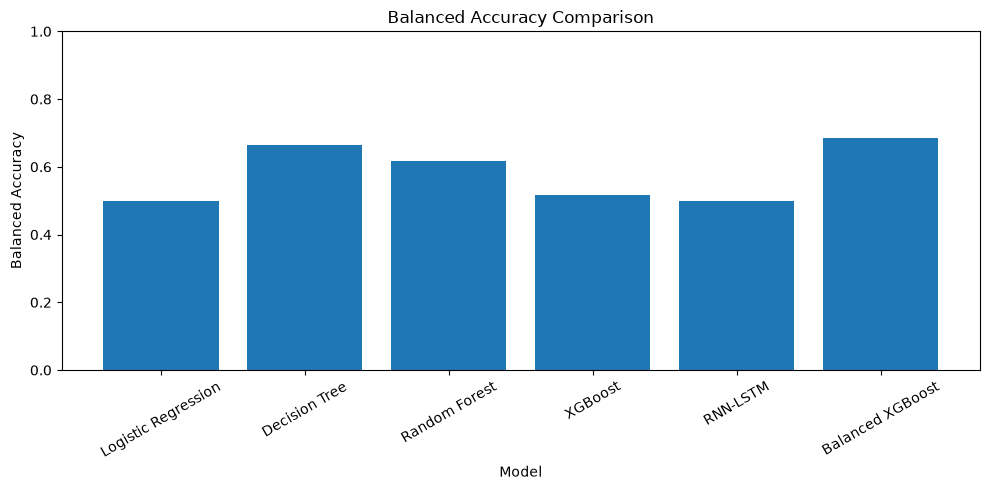

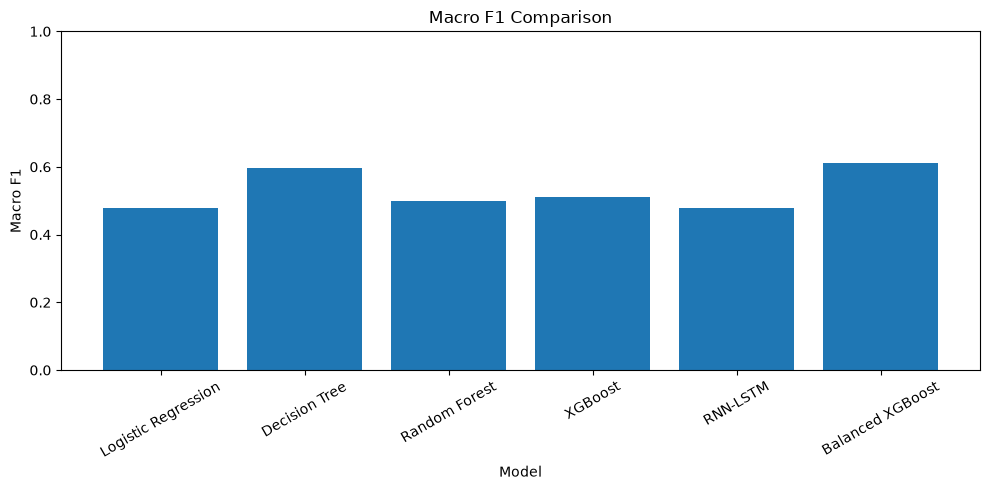

In [55]:
import matplotlib.pyplot as plt

# Plot Balanced Accuracy
plt.figure(figsize=(10, 5))
plt.bar(
    final_comparison_df["Model"],
    final_comparison_df["Balanced Accuracy"]
)
plt.ylabel("Balanced Accuracy")
plt.xlabel("Model")
plt.title("Balanced Accuracy Comparison")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


# Plot Macro F1
plt.figure(figsize=(10, 5))
plt.bar(
    final_comparison_df["Model"],
    final_comparison_df["Macro F1"]
)
plt.ylabel("Macro F1")
plt.xlabel("Model")
plt.title("Macro F1 Comparison")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [56]:
# Save final model comparison

final_comparison_df.to_csv(
    "final_model_comparison.csv",
    index=False
)

print("Final model comparison saved successfully!")

Final model comparison saved successfully!


In [57]:
from sklearn.metrics import roc_auc_score, average_precision_score

# Get prediction probabilities

lr_prob = lr_model.predict_proba(X_val)[:, 1]
dt_prob = dt_model.predict_proba(X_val)[:, 1]
rf_prob = rf_model.predict_proba(X_val)[:, 1]
xgb_prob = xgb_model.predict_proba(X_val)[:, 1]

# Balanced XGBoost probabilities
xgb_balanced_prob = xgb_balanced.predict_proba(X_val)[:, 1]

# LSTM probabilities were already calculated
lstm_prob = y_val_lstm_prob

auc_results = []

for model_name, y_true, probabilities in [
    ("Logistic Regression", y_val, lr_prob),
    ("Decision Tree", y_val, dt_prob),
    ("Random Forest", y_val, rf_prob),
    ("XGBoost", y_val, xgb_prob),
    ("RNN-LSTM", y_val_lstm, lstm_prob),
    ("Balanced XGBoost", y_val, xgb_balanced_prob)
]:
    
    auc_results.append({
        "Model": model_name,
        "ROC-AUC": roc_auc_score(y_true, probabilities),
        "PR-AUC": average_precision_score(y_true, probabilities)
    })

auc_results_df = pd.DataFrame(auc_results)

print("ROC-AUC and PR-AUC Comparison")
display(auc_results_df.round(4))

ROC-AUC and PR-AUC Comparison


,Model,ROC-AUC,PR-AUC
0,Logistic Regression,0.5185,0.9223
1,Decision Tree,0.6844,0.9449
2,Random Forest,0.6797,0.9523
3,XGBoost,0.7502,0.9653
4,RNN-LSTM,0.5000,0.9183
5,Balanced XGBoost,0.7524,0.9657


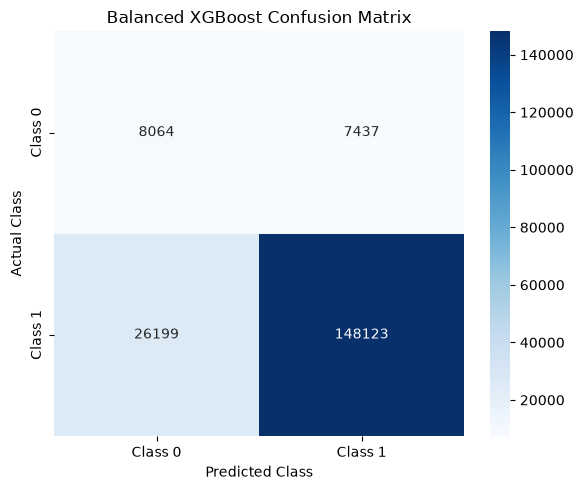

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_val,
    y_val_xgb_balanced_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Class 0", "Class 1"],
    yticklabels=["Class 0", "Class 1"]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Balanced XGBoost Confusion Matrix")

plt.tight_layout()
plt.show()